In [ ]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.metrics import roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgbm
from sklearn.preprocessing import StandardScaler

from hyperopt import hp
from hyperopt import fmin, tpe, Trials, STATUS_OK
from hyperopt import space_eval

# from utils import user_utils
from utils import preprocessing

In [ ]:
train_df = pd.read_csv("../data/train.csv")
X = train_df.drop("TARGET", axis=1)
y = train_df["TARGET"]

# 3. 학습/검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. DummyClassifier 생성 및 학습
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = dummy_clf.predict(X_test)

print("DummyClassifier Accuracy:", accuracy_score(y_test, y_pred))

DummyClassifier Accuracy: 0.9604051565377533


In [ ]:
# data loading
train_df, test_df = preprocessing.load_data()
test_df = test_df.drop(["ID"], axis=1)

In [5]:
X_features, y_target = preprocessing.split_features_target(train_df)

In [ ]:
X_features["var3"] = X_features["var3"].replace(-999999, 2)

In [7]:
# 컬럼 삭제 ,결측치 처리 및 스탠다드 스케일처
# from common.preprocessing import load_data
scaled_X_train, scaled_X_test, scaler = preprocessing.scale_data(X_features, test_df)

In [8]:
X_train, X_val, y_train, y_val = preprocessing.data_split(scaled_X_train, y_target)

In [ ]:
# --- 2. Hyperparameter 탐색 공간 정의 ---

# XGBoost 탐색 공간
xgb_search_space = {
    "max_depth": hp.quniform("max_depth", 5, 15, 1),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.2),
    "n_estimators": hp.quniform("n_estimators", 100, 1000, 10),
    "min_child_weight": hp.quniform("min_child_weight", 1, 6, 1),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 1.0),
    "gamma": hp.uniform("gamma", 0, 0.5),
}

# LightGBM 탐색 공간
lgbm_search_space = {
    "num_leaves": hp.quniform("num_leaves", 32, 128, 1),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.2),
    "n_estimators": hp.quniform("n_estimators", 100, 1000, 10),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0, 1),
    "reg_lambda": hp.uniform("reg_lambda", 0, 1),
}

# RandomForest 탐색 공간
rf_search_space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 10),
    "max_depth": hp.quniform("max_depth", 10, 30, 1),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 8, 1),
    "min_samples_split": hp.quniform("min_samples_split", 2, 12, 1),
}

In [ ]:
def xgb_objective(params):
    """XGBoost 목적 함수"""
    params["max_depth"] = int(params["max_depth"])
    params["n_estimators"] = int(params["n_estimators"])

    xgb = XGBClassifier(
        **params,
        eval_metric="auc",
        use_label_encoder=False,
        early_stopping_rounds=30,
        random_state=23
    )

    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    roc_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])

    return {"loss": -roc_auc, "status": STATUS_OK}


def lgbm_objective(params):
    """LightGBM 목적 함수"""
    params["num_leaves"] = int(params["num_leaves"])
    params["n_estimators"] = int(params["n_estimators"])

    lgbm = LGBMClassifier(
        **params, random_state=23, early_stopping_rounds=30, verbose=-1
    )

    lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)])

    roc_auc = roc_auc_score(y_val, lgbm.predict_proba(X_val)[:, 1])

    return {"loss": -roc_auc, "status": STATUS_OK}


def rf_objective(params):
    """RandomForest 목적 함수"""
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])
    params["min_samples_split"] = int(params["min_samples_split"])

    rf = RandomForestClassifier(**params, random_state=23, n_jobs=-1)

    rf.fit(X_train, y_train)
    roc_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])

    return {"loss": -roc_auc, "status": STATUS_OK}

In [ ]:
MAX_EVALS = 50

# XGBoost 튜닝
print("\n--- XGBoost Hyperparameter Tuning ---")
start_time = time.time()
xgb_trials = Trials()
best_xgb = fmin(
    fn=xgb_objective,
    space=xgb_search_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=xgb_trials,
    rstate=np.random.default_rng(seed=23),
)
end_time = time.time()
print(f"튜닝 시간: {end_time - start_time:.2f}초")
print("최적 하이퍼파라미터:", best_xgb)
print("최고 AUC:", -xgb_trials.best_trial["result"]["loss"])

# 실제 하이퍼파라미터 딕셔너리로 변환
best_params = space_eval(xgb_search_space, best_xgb)

# 정수형 파라미터 변환
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])

# 최적 파라미터로 모델 생성 및 학습
xgb_best = XGBClassifier(
    **best_params, eval_metric="auc", use_label_encoder=False, random_state=23
)

user_utils.get_model_train_eval(
    xgb_best, "xgb_HyperOpt_ejm", X_train, X_val, y_train, y_val
)


--- XGBoost Hyperparameter Tuning ---
  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 50/50 [01:50<00:00,  2.21s/trial, best loss: -0.8526307778345569]
튜닝 시간: 110.33초
최적 하이퍼파라미터: {'colsample_bytree': np.float64(0.8828333771389649), 'gamma': np.float64(0.058408742978283044), 'learning_rate': np.float64(0.12721361071578832), 'max_depth': np.float64(6.0), 'min_child_weight': np.float64(2.0), 'n_estimators': np.float64(320.0), 'subsample': np.float64(0.845580758889997)}
최고 AUC: 0.8526307778345569
✓ 모델 저장 완료: models\xgb_HyperOpt_ejm.pkl
  파일 크기: 0.82 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8324, 정확도: 0.9599, 정밀도: 0.3333, 재현율: 0.0116, F1: 0.0225
오차행렬:
[[14588    14]
 [  595     7]]
실행 시간: 4.026152849197388


In [ ]:
# LightGBM 튜닝
print("\n--- LightGBM Hyperparameter Tuning ---")
start_time = time.time()
lgbm_trials = Trials()
best_lgbm = fmin(
    fn=lgbm_objective,
    space=lgbm_search_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=lgbm_trials,
    rstate=np.random.default_rng(seed=23),
)
end_time = time.time()
print(f"튜닝 시간: {end_time - start_time:.2f}초")
print("최적 하이퍼파라미터:", best_lgbm)
print("최고 AUC:", -lgbm_trials.best_trial["result"]["loss"])

best_lgb = space_eval(lgbm_search_space, best_lgbm)
best_lgb["num_leaves"] = int(best_lgb["num_leaves"])
best_lgb["n_estimators"] = int(best_lgb["n_estimators"])

lgbm_best = LGBMClassifier(**best_lgb, random_state=23)

user_utils.get_model_train_eval(
    lgbm_best, "lgbm_HyperOpt_ejm", X_train, X_val, y_train, y_val
)


--- LightGBM Hyperparameter Tuning ---
100%|██████████| 50/50 [01:34<00:00,  1.88s/trial, best loss: -0.8528572179390163]
튜닝 시간: 94.20초
최적 하이퍼파라미터: {'colsample_bytree': np.float64(0.7342406115797382), 'learning_rate': np.float64(0.02751826185901235), 'n_estimators': np.float64(660.0), 'num_leaves': np.float64(42.0), 'reg_alpha': np.float64(0.6127977982911577), 'reg_lambda': np.float64(0.1262561992869149), 'subsample': np.float64(0.973776538266153)}
최고 AUC: 0.8528572179390163
✓ 모델 저장 완료: models\lgbm_HyperOpt_ejm.pkl
  파일 크기: 2.89 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8438, 정확도: 0.9605, 정밀도: 0.6000, 재현율: 0.0050, F1: 0.0099
오차행렬:
[[14600     2]
 [  599     3]]
실행 시간: 4.948836803436279


In [ ]:
# RandomForest 튜닝
print("\n--- RandomForest Hyperparameter Tuning ---")
start_time = time.time()
rf_trials = Trials()
best_rf = fmin(
    fn=rf_objective,
    space=rf_search_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=rf_trials,
    rstate=np.random.default_rng(seed=23),
)
end_time = time.time()
print(f"튜닝 시간: {end_time - start_time:.2f}초")
print("최적 하이퍼파라미터:", best_rf)
print("최고 AUC:", -rf_trials.best_trial["result"]["loss"])

best_rf = space_eval(rf_search_space, best_rf)

best_rf["n_estimators"] = int(best_rf["n_estimators"])
best_rf["max_depth"] = int(best_rf["max_depth"])
best_rf["min_samples_leaf"] = int(best_rf["min_samples_leaf"])
best_rf["min_samples_split"] = int(best_rf["min_samples_split"])

rf_best = RandomForestClassifier(**best_rf, random_state=23, n_jobs=-1)

user_utils.get_model_train_eval(
    rf_best, "rf_HyperOpt_ejm", X_train, X_val, y_train, y_val
)

print("\nHyperparameter 튜닝이 완료되었습니다.")


--- RandomForest Hyperparameter Tuning ---
100%|██████████| 50/50 [11:23<00:00, 13.67s/trial, best loss: -0.836193990628872] 
튜닝 시간: 683.38초
최적 하이퍼파라미터: {'max_depth': np.float64(25.0), 'min_samples_leaf': np.float64(1.0), 'min_samples_split': np.float64(7.0), 'n_estimators': np.float64(390.0)}
최고 AUC: 0.836193990628872
✓ 모델 저장 완료: models\rf_HyperOpt_ejm.pkl
  파일 크기: 65.74 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8362, 정확도: 0.9605, 정밀도: 0.6000, 재현율: 0.0050, F1: 0.0099
오차행렬:
[[14600     2]
 [  599     3]]
실행 시간: 18.158472299575806

Hyperparameter 튜닝이 완료되었습니다.


In [ ]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
# ID와 TARGET 분리
X = train.drop(["ID", "TARGET"], axis=1)
y = train["TARGET"]
test_ids = test["ID"]
X_test = test.drop(["ID"], axis=1)

# Var3 이상치 처리
print(f"\nVar3 이상치 처리 전 unique 값: {X['var3'].unique()}")
X["var3"] = X["var3"].replace(-999999, 2)
X_test["var3"] = X_test["var3"].replace(-999999, 2)
print(f"Var3 이상치 처리 후 unique 값: {X['var3'].unique()}")

# 행 전체가 0인 피처 삭제
zero_cols = X.columns[(X == 0).all()]
print(f"\n행 전체가 0인 피처 개수: {len(zero_cols)}")
if len(zero_cols) > 0:
    X = X.drop(zero_cols, axis=1)
    X_test = X_test.drop(zero_cols, axis=1)
    print(f"삭제된 피처: {list(zero_cols)[:10]}...")

# 상관계수 0.95 이상인 피처 삭제
print("\n상관계수 높은 피처 삭제 중...")
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_features = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)
]
print(f"상관계수 0.95 이상 피처 개수: {len(high_corr_features)}")
if len(high_corr_features) > 0:
    X = X.drop(high_corr_features, axis=1)
    X_test = X_test.drop(high_corr_features, axis=1)
    print(f"삭제된 피처 예시: {high_corr_features[:5]}")

print(f"\n전처리 후 피처 개수: {X.shape[1]}")

# StandardScaler 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
models = {}
feature_importances = {}

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="auc",
)
xgb_model.fit(X_train, y_train)
models["XGBoost"] = xgb_model
feature_importances["XGBoost"] = pd.DataFrame(
    {"feature": X.columns, "importance": xgb_model.feature_importances_}
).sort_values("importance", ascending=False)
print(f"XGBoost 검증 정확도: {xgb_model.score(X_val, y_val):.4f}")

# LightGBM
print("\n[2/3] LightGBM 학습 중...")
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3,
    random_state=42,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)
models["LightGBM"] = lgb_model
feature_importances["LightGBM"] = pd.DataFrame(
    {"feature": X.columns, "importance": lgb_model.feature_importances_}
).sort_values("importance", ascending=False)
print(f"LightGBM 검증 정확도: {lgb_model.score(X_val, y_val):.4f}")

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
models["RandomForest"] = rf_model
feature_importances["RandomForest"] = pd.DataFrame(
    {"feature": X.columns, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)
print(f"Random Forest 검증 정확도: {rf_model.score(X_val, y_val):.4f}")

lr_model = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=42, solver="liblinear"
)
lr_model.fit(X_train, y_train)
models["LogisticRegression"] = lr_model
# Logistic Regression은 계수의 절댓값을 중요도로 사용
feature_importances["LogisticRegression"] = pd.DataFrame(
    {"feature": X.columns, "importance": np.abs(lr_model.coef_[0])}
).sort_values("importance", ascending=False)
print(f"Logistic Regression 검증 정확도: {lr_model.score(X_val, y_val):.4f}")


Var3 이상치 처리 전 unique 값: [      2     229     178       0       8       3       4      10     110
       7     177       1       6     137      17 -999999      13      14
     148       5      11      15     122      22       9      58     121
      12     127      33     125     209      72      31      51      16
     107     174     141     191     104     129      18      49      73
      94     131     219     187     114      28      89     115      53
     126      47      84     235     161     197      23      30     146
     158     138      26     120      66     216     215      90      20
      21     103     192     142      29     163     223      95      98
      38     156      97     105     150     183     184      52      54
     220      25     225      86     124      27     162      19     195
     218      24      60     108      82      36     102     175     144
     169      64     201      79      91     159     135      45      61
     189     118     168  

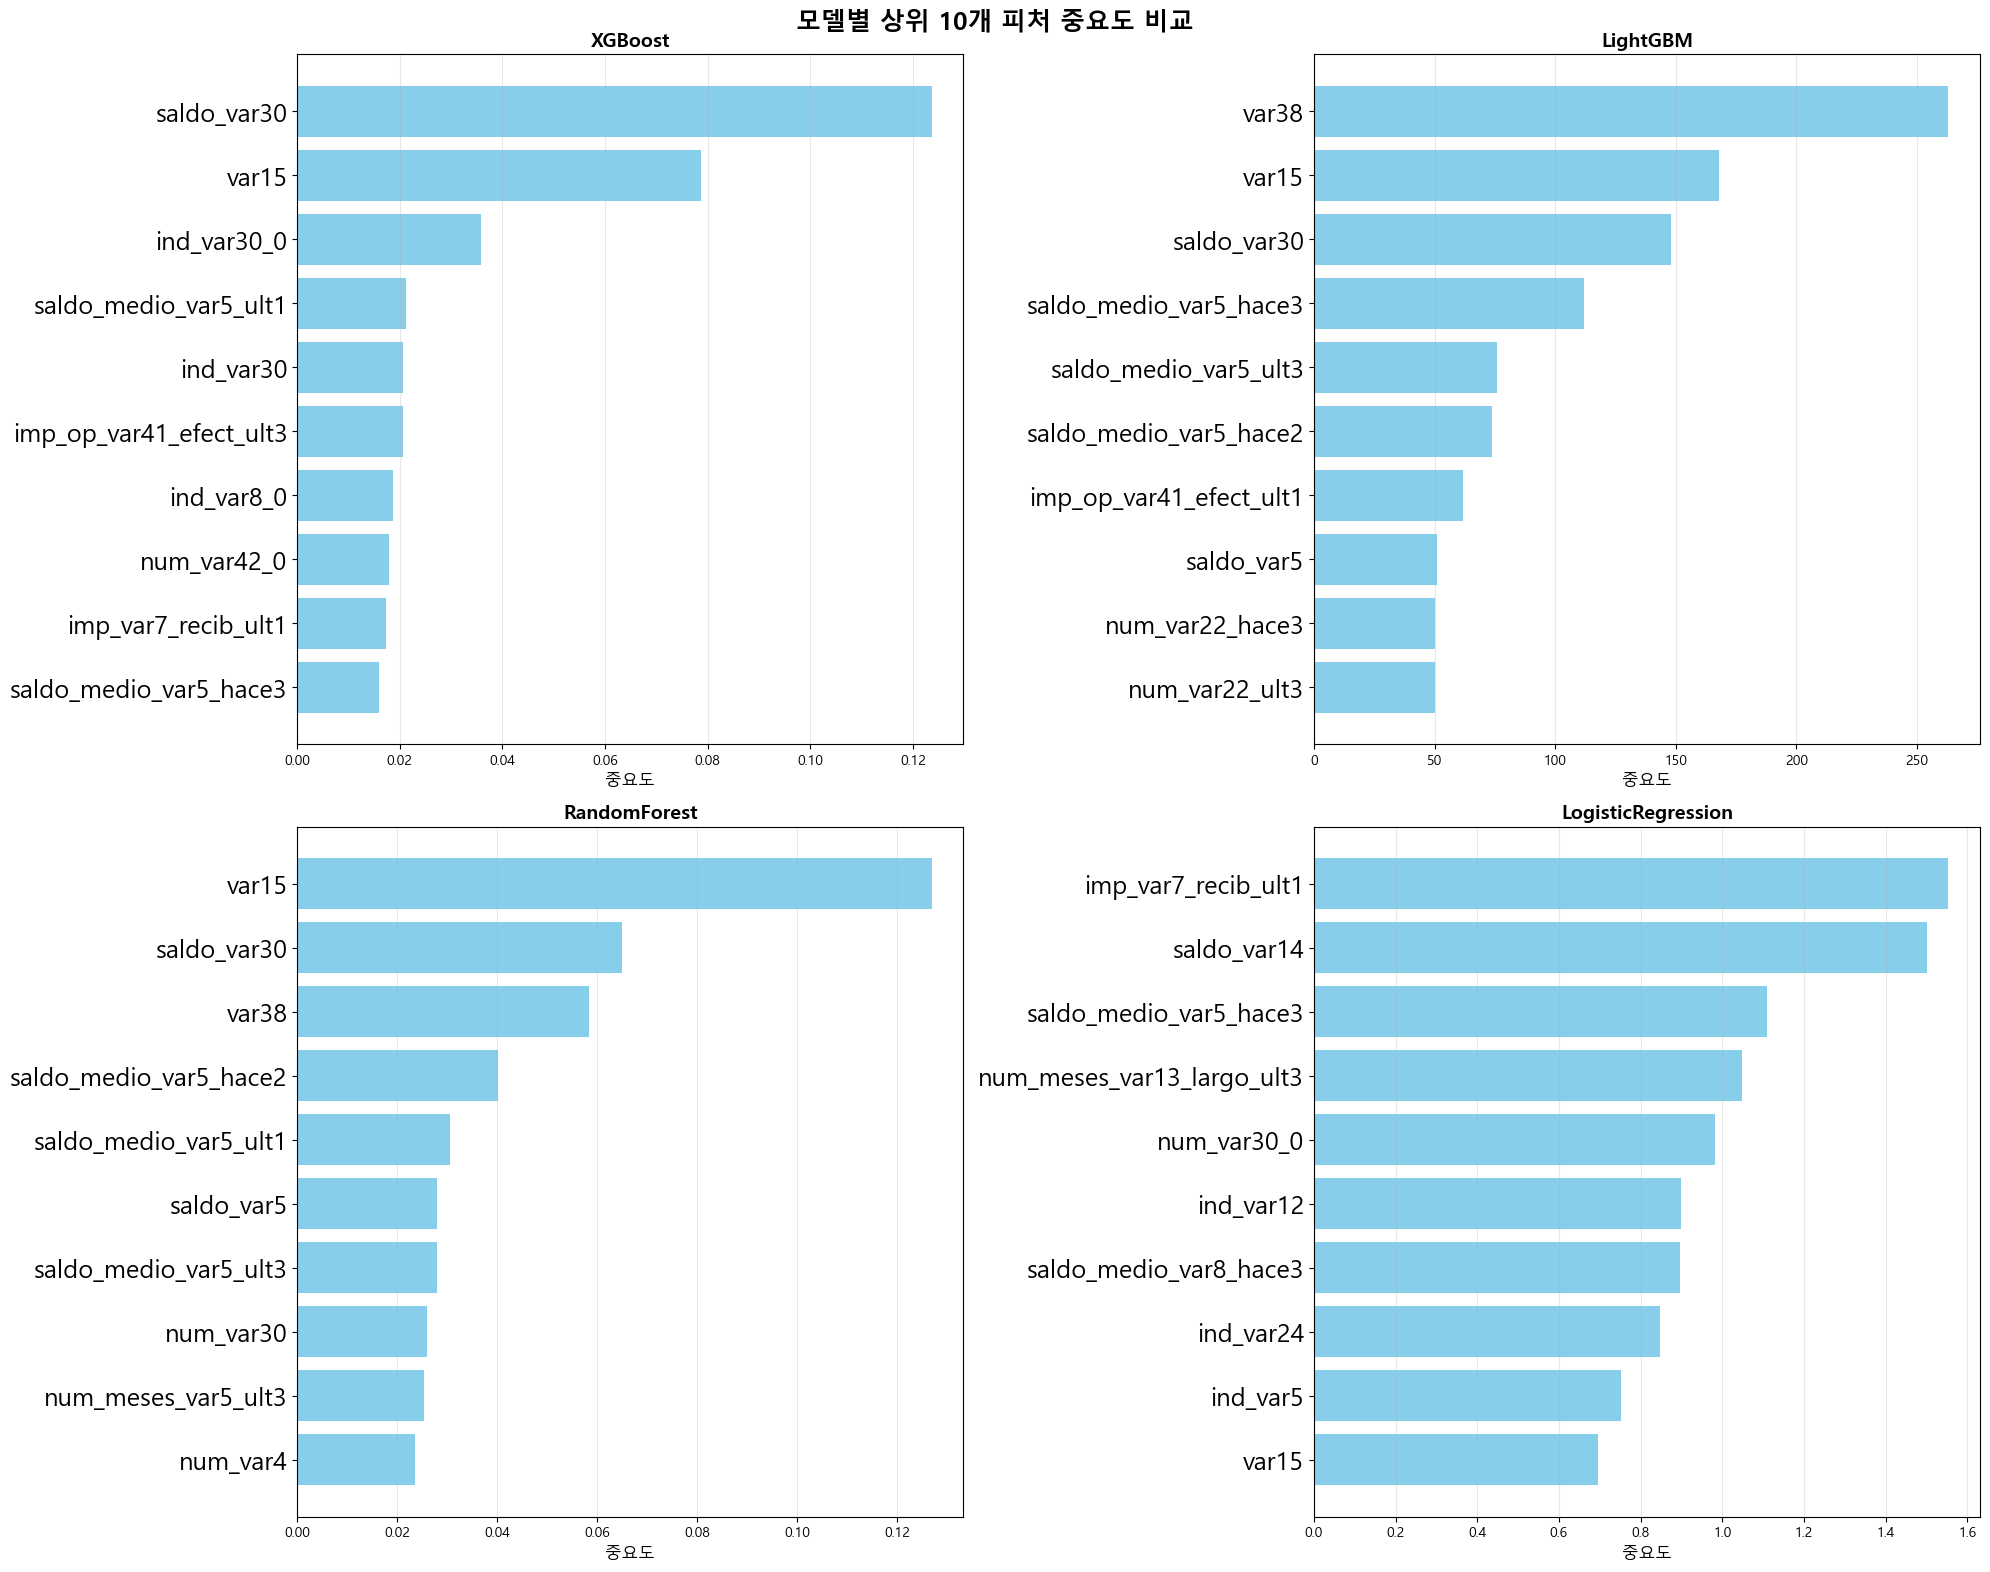

In [ ]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle("모델별 상위 10개 피처 중요도 비교", fontsize=18, fontweight="bold")

axes = axes.flatten()

for idx, (model_name, importance_df) in enumerate(feature_importances.items()):
    top_features = importance_df.head(10)

    axes[idx].barh(
        range(len(top_features)), top_features["importance"], color="skyblue"
    )
    axes[idx].set_yticks(range(len(top_features)))
    axes[idx].set_yticklabels(top_features["feature"], fontsize=18)
    axes[idx].set_xlabel("중요도", fontsize=12)
    axes[idx].set_title(f"{model_name}", fontsize=14, fontweight="bold")
    axes[idx].invert_yaxis()
    axes[idx].grid(axis="x", alpha=0.3)

plt.tight_layout()


Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 369
Test rows: 75,818, columns: 369

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020                 100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
              saldo_var2_ult1       0        1      0.000000     76020

c:\Users\tj\.conda\envs\ml_dev\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


----- 전역적 피처 중요도 (Summary Plot) -----


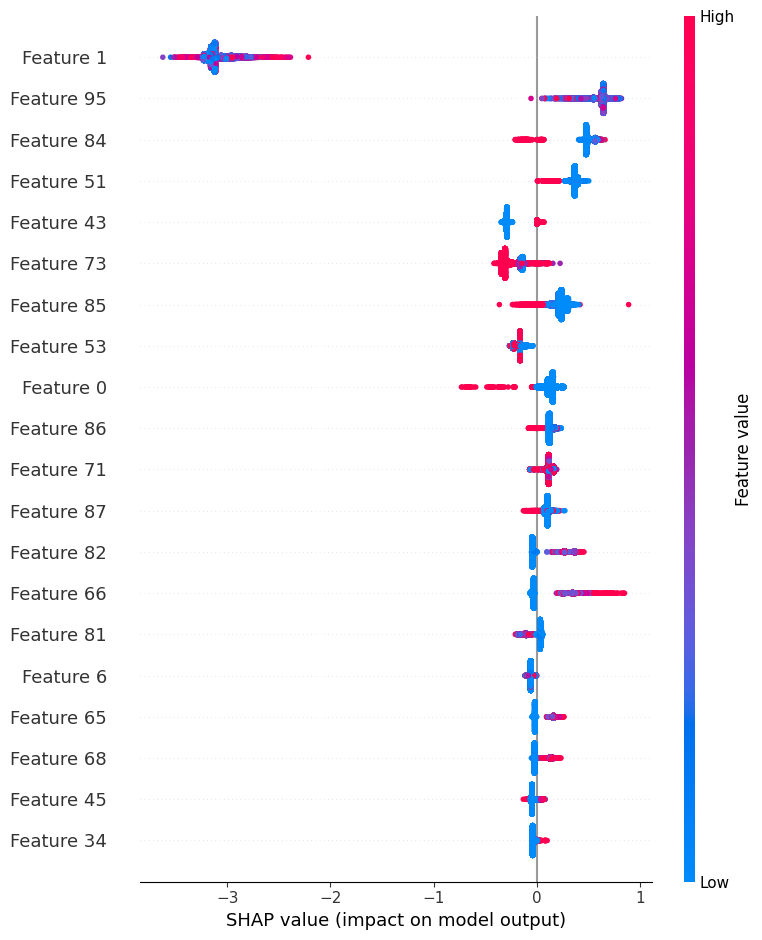

In [15]:
# 필요한 라이브러리 임포트 (shap, lightgbm)
import sys

project_root = "c:/big20/git/big20-ML-project2-team3/SantanderCS"
# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
import numpy as np
import pandas as pd

from utils.preprocessing import (
    load_data,
    split_features_target,
    scale_data,
    data_split,
    remove_zero_columns2,
)
from utils.feature_engineering import drop_highly_correlated_features

import shap

shap.initjs()

import lightgbm as lgb
import pickle

# 데이터 로딩 및 기본 전처리
train, test = load_data()
X_features, y_labels = split_features_target(train)
X_test = test.drop(columns=["ID"], axis=1)

# zero_count_rate 제거했을때 제거될 컬럼수 149개 잔존
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)

print(X_features.shape)

# var3 처리
X_features["var3"] = X_features["var3"].replace(-999999, 2)

# 상관계수 높은 feature들 삭제하기 default 0.95
X_reduced, to_drop = drop_highly_correlated_features(X_features)
X_test_reduced = X_test.drop(to_drop, axis=1)

X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)

# 학습/테스트 데이터 분리
X_train, X_val, y_train, y_val = data_split(X_train_scaled, y_labels)

# 모델 로딩
with open("../models/LightGBM_99per_Corr_weight110.pkl", "rb") as f:
    lgbm_model = pickle.load(f)

# 2. SHAP Explainer 생성 (트리 기반 모델이므로 TreeExplainer 사용)
explainer = shap.TreeExplainer(lgbm_model)

# 3. SHAP 값 계산
shap_values = explainer.shap_values(X_val)

# 4. 전역적 피처 중요도 시각화 (모델 전체에 대한 요약)
print("----- 전역적 피처 중요도 (Summary Plot) -----")
shap.summary_plot(shap_values, X_val)

# 5. 지역적 피터 중요도 시각화
shap.force_plot(explainer.expected_value, shap_values[0], X_val[0])